# Clasificación de Dígitos Escritos a Mano con Random Forest

Este notebook implementa un pipeline completo de **aprendizaje automático supervisado** para reconocer dígitos escritos a mano (0–9) utilizando el dataset `digits` de scikit-learn.

# Comprueba el entorno de ejecución
Usando `!` como prefijo, puedes ejecutar comandos de terminal directamente desde el notebook. Esto es útil para verificar que tienes las bibliotecas necesarias instaladas.

In [1]:
!python3 --version
!python3 -m pip list

Python 3.10.20
Package                   Version     Build
------------------------- ----------- -----
accelerate                1.13.0
annotated-doc             0.0.4
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.5
click                     8.3.1
comm                      0.2.3
contourpy                 1.3.2
cuda-bindings             12.9.4
cuda-pathfinder           1.4.2
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
exceptiongroup            1.3.1
executing                 2.2.1
fastjsonschema            2.21.2
filelock          

# Importa las bibliotecas necesarias

In [2]:
import math

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Carga el dataset de dígitos
El dataset `digits` contiene imágenes de dígitos escritos a mano, cada una representada como una matriz de píxeles. Cada imagen tiene una etiqueta correspondiente que indica el dígito representado.

In [3]:
digits = load_digits()

X = digits.data
y = digits.target

print("Número de muestras:", X.shape[0])
print("Número de features:", X.shape[1])
print("Primeras etiquetas:", y[:10])

Número de muestras: 1797
Número de features: 64
Primeras etiquetas: [0 1 2 3 4 5 6 7 8 9]


# Muestrea algunas imágenes del dataset

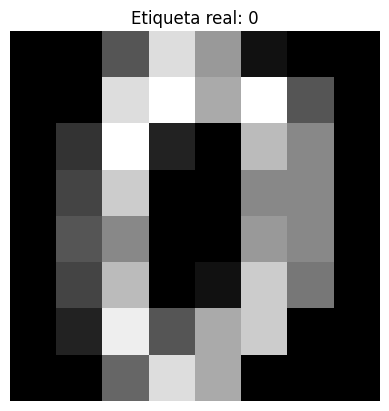

In [4]:
index = 0

plt.imshow(digits.images[index], cmap="gray")
plt.title(f"Etiqueta real: {digits.target[index]}")
plt.axis("off")
plt.show()

# Prepara los datos para el entrenamiento
Antes de entrenar el modelo, es importante dividir los datos en conjuntos de entrenamiento y prueba. Esto nos permitirá evaluar el rendimiento del modelo en datos no vistos durante el entrenamiento.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrena un modelo de Random Forest
El modelo de Random Forest es un algoritmo de aprendizaje automático que utiliza múltiples árboles de decisión. En este caso, 100.

In [6]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Valida el modelo
Después de entrenar el modelo, es crucial evaluar su rendimiento utilizando el conjunto de prueba. Esto nos dará una idea de cómo se desempeñará el modelo en datos nuevos.

In [7]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9722222222222222


# Muestrea una imagen bien clasificada con su predicción
Aquí mostramos una imagen del conjunto de prueba que el modelo clasificó correctamente, junto con su etiqueta real y la predicción del modelo.

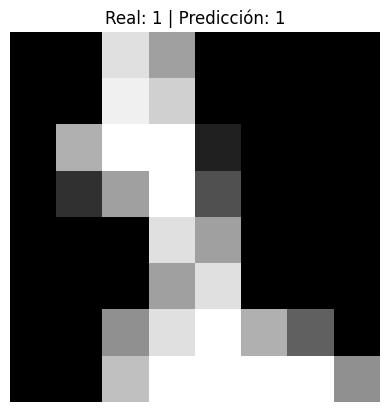

In [8]:
i = 5

plt.imshow(X_test[i].reshape(8, 8), cmap="gray")
plt.title(f"Real: {y_test[i]} | Predicción: {predictions[i]}")
plt.axis("off")
plt.show()


# Muestra los errores de clasificación

Número de errores: 10


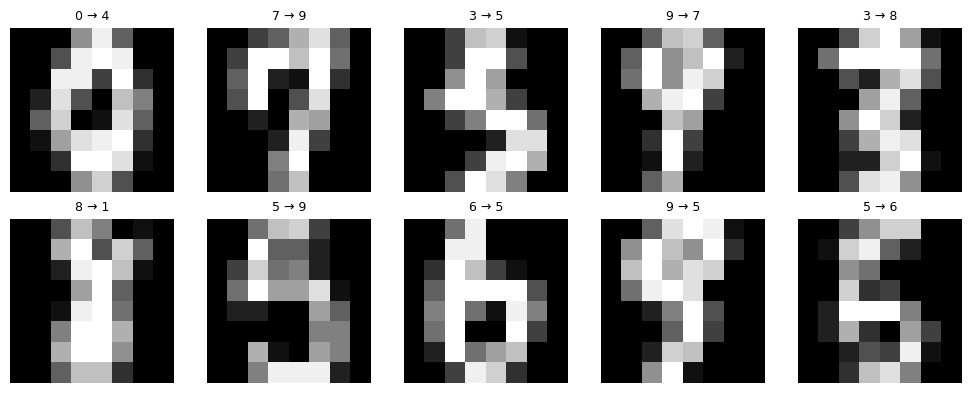

In [9]:
errors = [i for i in range(len(y_test)) if y_test[i] != predictions[i]]

print("Número de errores:", len(errors))

if errors:
    cols = 5
    rows = math.ceil(len(errors) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

    axes = axes.flatten()

    for ax, idx in zip(axes, errors):
        ax.imshow(X_test[idx].reshape(8, 8), cmap="gray")
        ax.set_title(f"{y_test[idx]} → {predictions[idx]}", fontsize=9)
        ax.axis("off")

    # apagar subplots sobrantes
    for ax in axes[len(errors):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()